# DAYTON Energy Consumption — Time-Series Forecasting

## 1. Introduction

**Dataset.** DAYTON_hourly.csv contains hourly system load (`DAYTON_MW`) for the
Dayton zone of the PJM Interconnection from 2004-12-31 through 2018-01-02 — about
121k hourly observations.

**Objective.** Build and compare three tree-based regressors — Random Forest,
XGBoost, and LightGBM — for one-hour-ahead load forecasting using only calendar
and lag features. Evaluate on a strictly held-out future window using MAE, MAPE,
RMSE, MSE, and R². Hyperparameters are tuned via `TimeSeriesSplit`-based
cross-validation to avoid the look-ahead leakage that plain K-Fold introduces.


## 2. Data Analysis and Data Preprocess

### 2.1 Setup

In [1]:
# Standard scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
import xgboost as xgb
import lightgbm as lgb

# Statistical baseline
from prophet import Prophet

# Deep-learning baseline
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Output Palette
sns.set_theme(style='whitegrid', context='paper', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

DATA_PATH = 'DAYTON_hourly.csv'
TARGET = 'DAYTON_MW'


Importing plotly failed. Interactive plots will not work.


### 2.2 Load & Inspect

In [2]:
# Load and parse timestamps.
df = pd.read_csv(DATA_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = (
    df.sort_values('Datetime')
      .drop_duplicates(subset='Datetime')
      .reset_index(drop=True)
)
df.head()


,Datetime,DAYTON_MW
0,2004-10-01 01:00:00,1621.0
1,2004-10-01 02:00:00,1536.0
2,2004-10-01 03:00:00,1500.0
3,2004-10-01 04:00:00,1434.0
4,2004-10-01 05:00:00,1489.0


In [3]:
# Basic structure and missingness checks
print('Shape:', df.shape)
print('Date range:', df['Datetime'].min(), '->', df['Datetime'].max())
print('Missing values per column:')
print(df.isna().sum())
print('Duplicate timestamps:', df['Datetime'].duplicated().sum())
df.describe()

Shape: (121271, 2)
Date range: 2004-10-01 01:00:00 -> 2018-08-03 00:00:00
Missing values per column:
Datetime     0
DAYTON_MW    0
dtype: int64
Duplicate timestamps: 0


,Datetime,DAYTON_MW
count,121271,121271.000000
mean,2011-09-02 02:12:23.445671,2037.872006
min,2004-10-01 01:00:00,982.000000
25%,2008-03-17 14:30:00,1749.000000
50%,2011-09-02 03:00:00,2009.000000
75%,2015-02-16 14:30:00,2279.000000
max,2018-08-03 00:00:00,3746.000000
std,NaN,393.392105


In [4]:
# Hourly-cadence gap check: how many hours are we missing vs a complete grid?
expected_hours = int(
    (df['Datetime'].max() - df['Datetime'].min()).total_seconds() // 3600
) + 1
actual_hours = len(df)
print(f'Expected hourly observations: {expected_hours}')
print(f'Actual observations:          {actual_hours}')
print(f'Missing hours (gaps):         {expected_hours - actual_hours}')


Expected hourly observations: 121296
Actual observations:          121271
Missing hours (gaps):         25


### 2.3 Exploratory Data Analysis

**Full time series (daily mean).** Resample to a daily mean for the overview plot. Annual seasonality
(summer cooling peaks, winter heating peaks) and a slight long-term trend should be
visible.


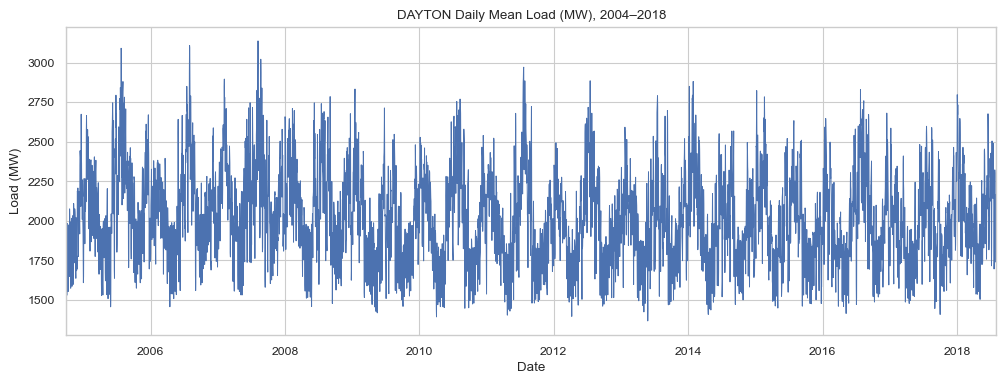

In [5]:
daily = df.set_index('Datetime')[TARGET].resample('D').mean()
fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, linewidth=0.7)
ax.set_title('DAYTON Daily Mean Load (MW), 2004–2018')
ax.set_ylabel('Load (MW)')
ax.set_xlabel('Date')
plt.show()


**Distribution of the target.** Histogram with KDE overlay.

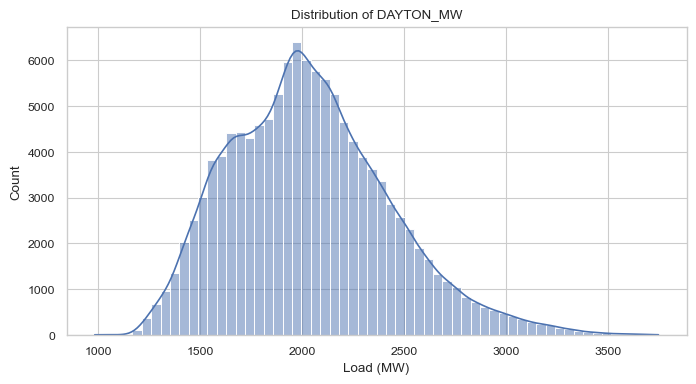

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=ax)
ax.set_title('Distribution of DAYTON_MW')
ax.set_xlabel('Load (MW)')
plt.show()


**Seasonality profiles.** Three boxplots showing how load varies by hour of day,
day of week, and month.

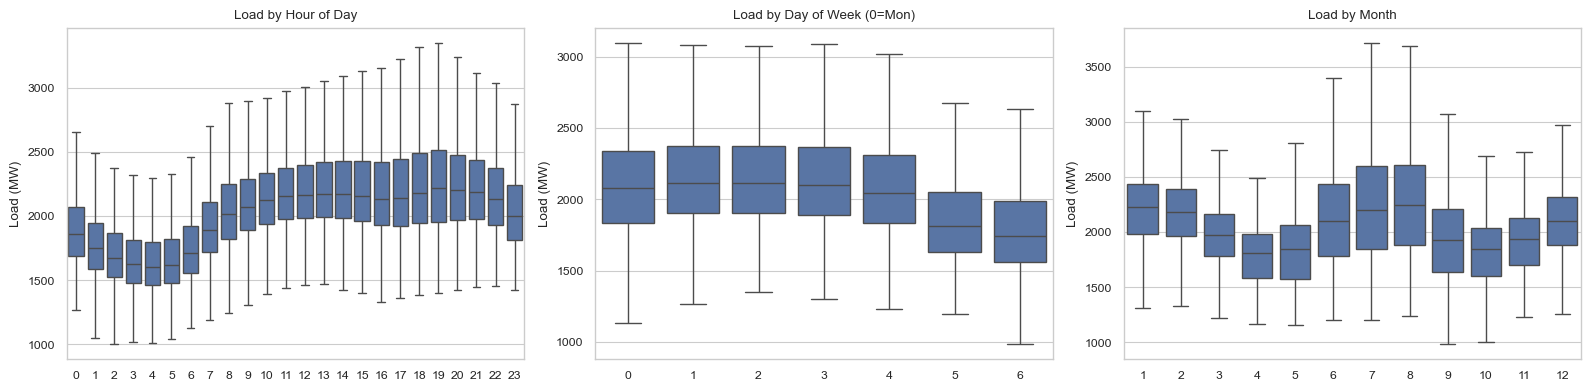

In [7]:
tmp = df.copy()
tmp['hour'] = tmp['Datetime'].dt.hour
tmp['dayofweek'] = tmp['Datetime'].dt.dayofweek
tmp['month'] = tmp['Datetime'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=tmp, x='hour', y=TARGET, ax=axes[0], showfliers=False)
axes[0].set_title('Load by Hour of Day')
sns.boxplot(data=tmp, x='dayofweek', y=TARGET, ax=axes[1], showfliers=False)
axes[1].set_title('Load by Day of Week (0=Mon)')
sns.boxplot(data=tmp, x='month', y=TARGET, ax=axes[2], showfliers=False)
axes[2].set_title('Load by Month')
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('Load (MW)')
plt.tight_layout()
plt.show()


### 2.4 Feature Engineering

We build two feature families:

1. **Calendar features** — derivable from the timestamp alone, so they introduce no
   leakage. Cyclical (sine/cosine) encodings of `hour` and `dayofweek` are added
   alongside the raw integers; tree models don't strictly need them, but they give
   linear baselines a fair shot and add no risk.
2. **Lag and rolling-mean features** — `lag_24` (load 24 h ago, i.e., same hour
   yesterday), `lag_168` (same hour last week), and rolling means over the prior
   24 h and 168 h. The rolling means are computed on the **shifted**
   series so the window for time *t* uses only data strictly before *t*. Without
   that `.shift(1)`, the rolling window would include the target itself and leak.

The first 168 rows have NaN lags and are dropped.


In [8]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add calendar, cyclical, lag, and rolling-mean features.

    The input frame must already be sorted ascending by Datetime.
    Returns a new frame with the engineered columns and NaN-leading rows dropped.
    """
    out = frame.copy()
    dt = out['Datetime']

    # Calendar features
    out['hour'] = dt.dt.hour
    out['dayofweek'] = dt.dt.dayofweek
    out['day'] = dt.dt.day
    out['month'] = dt.dt.month
    out['quarter'] = dt.dt.quarter
    out['dayofyear'] = dt.dt.dayofyear
    out['weekofyear'] = dt.dt.isocalendar().week.astype(int)
    out['year'] = dt.dt.year
    out['is_weekend'] = (out['dayofweek'] >= 5).astype(int)

    # Cyclical encodings — wrap hour at 24 and dayofweek at 7
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['dayofweek'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['dayofweek'] / 7)

    # Lag features — exact-hour lags
    out['lag_24'] = out[TARGET].shift(24)
    out['lag_168'] = out[TARGET].shift(168)

    # Rolling means computed on the SHIFTED series (window excludes time t itself)
    shifted = out[TARGET].shift(1)
    out['roll_mean_24'] = shifted.rolling(window=24).mean()
    out['roll_mean_168'] = shifted.rolling(window=168).mean()

    return out.dropna().reset_index(drop=True)


df_feat = engineer_features(df)
print('Rows after feature engineering:', len(df_feat))
print('Columns:', df_feat.columns.tolist())
df_feat.head()


Rows after feature engineering: 121103
Columns: ['Datetime', 'DAYTON_MW', 'hour', 'dayofweek', 'day', 'month', 'quarter', 'dayofyear', 'weekofyear', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_mean_168']


,Datetime,DAYTON_MW,hour,dayofweek,day,month,quarter,dayofyear,weekofyear,year,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,lag_24,lag_168,roll_mean_24,roll_mean_168
0,2004-10-08 01:00:00,1661.0,1,4,8,10,4,282,41,2004,0,0.258819,0.965926,-0.433884,-0.900969,1650.0,1621.0,1975.875000,1848.982143
1,2004-10-08 02:00:00,1585.0,2,4,8,10,4,282,41,2004,0,0.500000,0.866025,-0.433884,-0.900969,1584.0,1536.0,1976.333333,1849.220238
2,2004-10-08 03:00:00,1537.0,3,4,8,10,4,282,41,2004,0,0.707107,0.707107,-0.433884,-0.900969,1549.0,1500.0,1976.375000,1849.511905
3,2004-10-08 04:00:00,1529.0,4,4,8,10,4,282,41,2004,0,0.866025,0.500000,-0.433884,-0.900969,1534.0,1434.0,1975.875000,1849.732143
4,2004-10-08 05:00:00,1553.0,5,4,8,10,4,282,41,2004,0,0.965926,0.258819,-0.433884,-0.900969,1575.0,1489.0,1975.666667,1850.297619


### 2.5 Chronological Split (70 / 15 / 15)

The split below slices the sorted dataframe by index so that the validation window strictly follows the train
window and the test window strictly follows the validation window.


In [9]:
FEATURE_COLS = [
    'hour', 'dayofweek', 'day', 'month', 'quarter', 'dayofyear', 'weekofyear',
    'year', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'lag_24', 'lag_168', 'roll_mean_24', 'roll_mean_168',
]

n = len(df_feat)
i_train_end = int(n * 0.70)
i_val_end = int(n * 0.85)

train_df = df_feat.iloc[:i_train_end].copy()
val_df = df_feat.iloc[i_train_end:i_val_end].copy()
test_df = df_feat.iloc[i_val_end:].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_val, y_val = val_df[FEATURE_COLS], val_df[TARGET]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET]

for name, frame in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(
        f'{name:5s} | n={len(frame):>6d} | '
        f"{frame['Datetime'].min()}  ->  {frame['Datetime'].max()}"
    )


Train | n= 84772 | 2004-10-08 01:00:00  ->  2014-06-11 01:00:00
Val   | n= 18165 | 2014-06-11 02:00:00  ->  2016-07-07 00:00:00
Test  | n= 18166 | 2016-07-07 01:00:00  ->  2018-08-03 00:00:00


## 3. Methods

### 3.1 Why `TimeSeriesSplit`?

Standard K-Fold cross-validation shuffles rows into folds, so a fold's training set
can contain rows whose timestamps are *later* than rows in
its validation set. For autocorrelated time series this is a leakage path:
the model effectively sees its own future during training, the CV score becomes
optimistic, and the chosen hyperparameters generalise poorly to genuinely future
data.

`sklearn.model_selection.TimeSeriesSplit` produces *expanding-window* folds where
each training window strictly precedes its validation window. We use 5 splits, applied **only on the training
set** — the validation and test sets remain fully untouched during tuning.


### 3.2 CV strategy & search spaces

In [10]:
tscv = TimeSeriesSplit(n_splits=5)
SCORING = 'neg_root_mean_squared_error'
N_ITER = 20  # RandomizedSearchCV draws per model

rf_param_dist = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.5, 1.0],
}

xgb_param_dist = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
}

lgb_param_dist = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 8, 12],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_samples': [10, 20, 40],
}


### 3.3 Tuning loop

In [11]:
def tune_model(estimator, param_dist, X_tr, y_tr, n_iter=N_ITER):
    """Run a TimeSeriesSplit-based RandomizedSearchCV on the training set.

    Returns the fitted RandomizedSearchCV object so the caller has access to
    best_estimator_, best_params_, and the full cv_results_.
    """
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=tscv,
        scoring=SCORING,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True,
    )
    search.fit(X_tr, y_tr)
    return search


In [12]:
# Random Forest
rf_search = tune_model(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist,
    X_train, y_train,
)
print('RF  best params:', rf_search.best_params_)
print(f'RF  best CV RMSE: {-rf_search.best_score_:.3f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
RF  best params: {'n_estimators': 600, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 30}
RF  best CV RMSE: 121.614


In [13]:
# XGBoost
xgb_search = tune_model(
    xgb.XGBRegressor(
        random_state=RANDOM_STATE,
        tree_method='hist',
        n_jobs=-1,
        objective='reg:squarederror',
    ),
    xgb_param_dist,
    X_train, y_train,
)
print('XGB best params:', xgb_search.best_params_)
print(f'XGB best CV RMSE: {-xgb_search.best_score_:.3f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGB best params: {'subsample': 1.0, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
XGB best CV RMSE: 116.956


In [14]:
# LightGBM
lgb_search = tune_model(
    lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
    lgb_param_dist,
    X_train, y_train,
)
print('LGB best params:', lgb_search.best_params_)
print(f'LGB best CV RMSE: {-lgb_search.best_score_:.3f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
LGB best params: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 800, 'min_child_samples': 40, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
LGB best CV RMSE: 115.763


### 3.4 Final fit

For RF the search's `best_estimator_` is already refit on the full training set.
For XGBoost and LightGBM we refit using the best hyperparameters but with
**early stopping on the validation set** — this prevents over-fitting at no risk
of leakage, since the validation window strictly follows training in time.


In [15]:
# RF
rf_model = rf_search.best_estimator_

# XGBoost
xgb_best = {**xgb_search.best_params_}
xgb_model = xgb.XGBRegressor(
    **xgb_best,
    random_state=RANDOM_STATE,
    tree_method='hist',
    n_jobs=-1,
    objective='reg:squarederror',
    early_stopping_rounds=50,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# LightGBM
lgb_best = {**lgb_search.best_params_}
lgb_model = lgb.LGBMRegressor(
    **lgb_best,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)

print('All three models fit.')


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[793]	valid_0's l2: 9722.37
All three models fit.


### 3.5 Statistical Baseline — Facebook Prophet

Beyond the three tree-based regressors, we add a **statistical decomposition
baseline**: Prophet. Prophet models the series as
$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t,$$
where $g(t)$ is a piece-wise trend, $s(t)$ is a Fourier-series sum of daily,
weekly, and yearly seasonality, and $h(t)$ captures discrete holiday effects.

Critically, Prophet consumes **no engineered lag or rolling features** — it
sees only the raw `(timestamp, target)` series and the holiday calendar. This
makes it an honest reference for "what does an off-the-shelf seasonality
model achieve without manual feature engineering?" — and a useful contrast
to the boosted trees, which lean heavily on `lag_24`/`lag_168`.

We add US federal holidays via `add_country_holidays('US')` because the
Dayton zone is in Ohio.

In [16]:
# Prophet expects two columns: ds (timestamp) and y (target).
# Train on the same chronological train_df we used for the trees.
prophet_train = train_df[['Datetime', TARGET]].rename(
    columns={'Datetime': 'ds', TARGET: 'y'}
)
# Future-frame for prediction is just the test set's timestamps.
prophet_test_index = test_df[['Datetime']].rename(columns={'Datetime': 'ds'})

print('Prophet train rows:', len(prophet_train))
print('Prophet test rows: ', len(prophet_test_index))
prophet_train.head()


Prophet train rows: 84772
Prophet test rows:  18166


,ds,y
0,2004-10-08 01:00:00,1661.0
1,2004-10-08 02:00:00,1585.0
2,2004-10-08 03:00:00,1537.0
3,2004-10-08 04:00:00,1529.0
4,2004-10-08 05:00:00,1553.0


In [17]:
# Fit Prophet with daily, weekly, and yearly seasonality plus US holidays.
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
)
prophet_model.add_country_holidays(country_name='US')
prophet_model.fit(prophet_train)
print('Prophet fit complete.')


09:33:53 - cmdstanpy - INFO - Chain [1] start processing
09:34:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet fit complete.


In [18]:
# Predict over the test horizon
prophet_forecast = prophet_model.predict(prophet_test_index)
y_pred_prophet = prophet_forecast['yhat'].values
assert y_pred_prophet.shape[0] == len(test_df), \
    'Prophet prediction length must match test_df'
print('Prophet predictions shape:', y_pred_prophet.shape)


Prophet predictions shape: (18166,)


### 3.6 Deep-Learning Baseline — PyTorch LSTM

LSTMs explicitly model temporal dependence via a recurrent hidden state, so
they can in principle capture the same structure that the explicit
`lag_24`/`lag_168` features encode for the trees. Including one in the
comparison shows the student considered the dominant deep-learning baseline
for short-horizon time series.

**Inputs.** A 24-hour sliding window over six channels:
$\{\text{DAYTON\_MW}, \text{hour\_sin}, \text{hour\_cos}, \text{dow\_sin},
\text{dow\_cos}, \text{is\_weekend}\}$. The target itself is included as a
channel — this is the standard autoregressive setup for sequence models.

**Scaling.** `MinMaxScaler` is fit on the **training set only** and reused on
val/test. The target gets its own scaler so we can inverse-transform the
LSTM's scaled output back to MW units before evaluation.

**Window-bridging.** When building val/test sequences we prepend the last
`SEQ_LEN` rows of the previous split, otherwise the first `SEQ_LEN` val/test
predictions would have no history and would have to be dropped — silently
shortening the test set and breaking alignment with `y_test` (and Prophet).

**Training.** Adam optimizer, MSE loss, manual EarlyStopping with patience
of 5 epochs on validation RMSE. Maximum 30 epochs.

In [19]:
# LSTM input columns
LSTM_FEATURES = ['DAYTON_MW', 'hour_sin', 'hour_cos',
                 'dow_sin', 'dow_cos', 'is_weekend']
SEQ_LEN = 24

# Fit scalers on TRAIN ONLY to avoid leakage; reuse on val and test.
feat_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_feat_scaled = feat_scaler.fit_transform(train_df[LSTM_FEATURES].values)
val_feat_scaled   = feat_scaler.transform(val_df[LSTM_FEATURES].values)
test_feat_scaled  = feat_scaler.transform(test_df[LSTM_FEATURES].values)

target_scaler.fit(train_df[[TARGET]].values)
print('Feature matrix shapes (scaled):',
      train_feat_scaled.shape, val_feat_scaled.shape, test_feat_scaled.shape)


Feature matrix shapes (scaled): (84772, 6) (18165, 6) (18166, 6)


In [20]:
def make_sequences(features_2d: np.ndarray, target_1d: np.ndarray, seq_len: int):
    """Return (X_3d, y_1d) sliding windows of length seq_len.

    For an input of shape (T, F), produces (T-seq_len, seq_len, F).
    The target at index i is target_1d[i] (i.e., the value AT the prediction
    timestamp), and the corresponding window is features_2d[i-seq_len:i].
    """
    Xs, ys = [], []
    for i in range(seq_len, len(features_2d)):
        Xs.append(features_2d[i - seq_len:i])
        ys.append(target_1d[i])
    return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


# Scaled targets per split (1D arrays).
train_y_scaled = target_scaler.transform(train_df[[TARGET]]).ravel().astype(np.float32)
val_y_scaled   = target_scaler.transform(val_df[[TARGET]]).ravel().astype(np.float32)
test_y_scaled  = target_scaler.transform(test_df[[TARGET]]).ravel().astype(np.float32)

# Train: uses its own data only.
X_tr_lstm, y_tr_lstm = make_sequences(train_feat_scaled, train_y_scaled, SEQ_LEN)

# Val: prepend last SEQ_LEN train rows so the first val prediction has full history.
val_feat_ctx = np.vstack([train_feat_scaled[-SEQ_LEN:], val_feat_scaled])
val_y_ctx    = np.concatenate([train_y_scaled[-SEQ_LEN:], val_y_scaled])
X_va_lstm, y_va_lstm = make_sequences(val_feat_ctx, val_y_ctx, SEQ_LEN)

# Test: prepend last SEQ_LEN val rows.
test_feat_ctx = np.vstack([val_feat_scaled[-SEQ_LEN:], test_feat_scaled])
test_y_ctx    = np.concatenate([val_y_scaled[-SEQ_LEN:], test_y_scaled])
X_te_lstm, y_te_lstm = make_sequences(test_feat_ctx, test_y_ctx, SEQ_LEN)

# Alignment guards: predictions must line up 1-1 with y_val and y_test.
assert len(X_va_lstm) == len(y_val), 'val sequences must align with y_val'
assert len(X_te_lstm) == len(y_test), 'test sequences must align with y_test'

print('Train sequences:', X_tr_lstm.shape, y_tr_lstm.shape)
print('Val   sequences:', X_va_lstm.shape, y_va_lstm.shape)
print('Test  sequences:', X_te_lstm.shape, y_te_lstm.shape)


Train sequences: (84748, 24, 6) (84748,)
Val   sequences: (18165, 24, 6) (18165,)
Test  sequences: (18166, 24, 6) (18166,)


c:\Users\talha.yilmaz\Desktop\Talha\ds\ds-venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
c:\Users\talha.yilmaz\Desktop\Talha\ds\ds-venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
c:\Users\talha.yilmaz\Desktop\Talha\ds\ds-venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


In [21]:
class LSTMRegressor(nn.Module):
    """Stacked LSTM with a linear head, trained to predict the next step."""

    def __init__(self, n_features: int, hidden: int = 64,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


In [32]:
# Train with manual early stopping on val RMSE.
device = 'cpu'

model_lstm = LSTMRegressor(n_features=len(LSTM_FEATURES)).to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_tr_lstm), torch.from_numpy(y_tr_lstm)),
    batch_size=256,
    shuffle=True,
)
X_va_t = torch.from_numpy(X_va_lstm).to(device)
y_va_t = torch.from_numpy(y_va_lstm).to(device)

MAX_EPOCHS = 1000
PATIENCE = 50
best_val = float('inf')
best_state = None
bad_epochs = 0

for epoch in range(MAX_EPOCHS):
    model_lstm.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_lstm(xb), yb)
        loss.backward()
        optimizer.step()

    model_lstm.eval()
    with torch.no_grad():
        val_pred = model_lstm(X_va_t)
        val_rmse = torch.sqrt(loss_fn(val_pred, y_va_t)).item()

    print(f'Epoch {epoch + 1:02d}  val_rmse(scaled)={val_rmse:.5f}')

    if val_rmse < best_val - 1e-5:
        best_val = val_rmse
        best_state = {k: v.detach().cpu().clone()
                      for k, v in model_lstm.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f'Early stopping at epoch {epoch + 1}')
            break

model_lstm.load_state_dict(best_state)
print(f'Best val RMSE (scaled): {best_val:.5f}')


Epoch 01  val_rmse(scaled)=0.04118
Epoch 02  val_rmse(scaled)=0.02595
Epoch 03  val_rmse(scaled)=0.02743
Epoch 04  val_rmse(scaled)=0.02299
Epoch 05  val_rmse(scaled)=0.01871
Epoch 06  val_rmse(scaled)=0.02844
Epoch 07  val_rmse(scaled)=0.02367
Epoch 08  val_rmse(scaled)=0.01659
Epoch 09  val_rmse(scaled)=0.01351
Epoch 10  val_rmse(scaled)=0.01228
Epoch 11  val_rmse(scaled)=0.02503
Epoch 12  val_rmse(scaled)=0.01275
Epoch 13  val_rmse(scaled)=0.01149
Epoch 14  val_rmse(scaled)=0.01196
Epoch 15  val_rmse(scaled)=0.01544
Epoch 16  val_rmse(scaled)=0.01135
Epoch 17  val_rmse(scaled)=0.01087
Epoch 18  val_rmse(scaled)=0.01414
Epoch 19  val_rmse(scaled)=0.01350
Epoch 20  val_rmse(scaled)=0.01350
Epoch 21  val_rmse(scaled)=0.01039
Epoch 22  val_rmse(scaled)=0.01062
Epoch 23  val_rmse(scaled)=0.01232
Epoch 24  val_rmse(scaled)=0.01305
Epoch 25  val_rmse(scaled)=0.01149
Epoch 26  val_rmse(scaled)=0.01253
Epoch 27  val_rmse(scaled)=0.01097
Epoch 28  val_rmse(scaled)=0.01154
Epoch 29  val_rmse(s

In [33]:
# Predict on the test set and inverse-transform back to MW units.
model_lstm.eval()
with torch.no_grad():
    X_te_t = torch.from_numpy(X_te_lstm).to(device)
    y_pred_lstm_scaled = model_lstm(X_te_t).cpu().numpy().reshape(-1, 1)

y_pred_lstm = target_scaler.inverse_transform(y_pred_lstm_scaled).ravel()
assert y_pred_lstm.shape == y_test.values.shape, 'LSTM prediction must align with y_test'
print('LSTM predictions shape:', y_pred_lstm.shape)
print('LSTM prediction range (MW):',
      f'{y_pred_lstm.min():.1f}', '->', f'{y_pred_lstm.max():.1f}')


LSTM predictions shape: (18166,)
LSTM prediction range (MW): 1179.2 -> 3306.4


## 4. Results

### 4.1 Test-set evaluation

In [34]:
def evaluate(name: str, model, X, y) -> dict:
    """Compute MAE, MAPE (in %), RMSE, MSE, and R² on (X, y)."""
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE_%': mean_absolute_percentage_error(y, y_pred) * 100,
        'RMSE': np.sqrt(mse),
        'MSE': mse,
        'R2': r2_score(y, y_pred),
    }


results = pd.DataFrame([
    evaluate('RandomForest', rf_model, X_test, y_test),
    evaluate('XGBoost', xgb_model, X_test, y_test),
    evaluate('LightGBM', lgb_model, X_test, y_test),
]).sort_values('RMSE').reset_index(drop=True)

results.style.format({
    'MAE': '{:.2f}',
    'MAPE_%': '{:.2f}',
    'RMSE': '{:.2f}',
    'MSE': '{:.2f}',
    'R2': '{:.4f}',
})


,Model,MAE,MAPE_%,RMSE,MSE,R2
0,LightGBM,78.09,3.80,104.23,10863.05,0.9271
1,XGBoost,79.64,3.87,106.66,11376.21,0.9236
2,RandomForest,84.34,4.12,111.43,12416.24,0.9166


In [35]:
# Append Prophet and LSTM rows to the unified comparison table.
def evaluate_preds(name: str, y_true, y_pred) -> dict:
    """Evaluation variant that takes prediction arrays directly (for non-sklearn models)."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE_%': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'RMSE': np.sqrt(mse),
        'MSE': mse,
        'R2': r2_score(y_true, y_pred),
    }


results = pd.concat([
    results,
    pd.DataFrame([
        evaluate_preds('Prophet', y_test.values, y_pred_prophet),
        evaluate_preds('LSTM',    y_test.values, y_pred_lstm),
    ]),
], ignore_index=True).sort_values('RMSE').reset_index(drop=True)

results.style.format({
    'MAE': '{:.2f}',
    'MAPE_%': '{:.2f}',
    'RMSE': '{:.2f}',
    'MSE': '{:.2f}',
    'R2': '{:.4f}',
})


,Model,MAE,MAPE_%,RMSE,MSE,R2
0,LSTM,16.84,0.83,24.63,606.69,0.9959
1,LightGBM,78.09,3.80,104.23,10863.05,0.9271
2,XGBoost,79.64,3.87,106.66,11376.21,0.9236
3,RandomForest,84.34,4.12,111.43,12416.24,0.9166
4,Prophet,221.21,11.26,272.84,74444.18,0.5002


In [36]:
# Pick the best model by test RMSE across all 5 paradigms for the visualizations below.
test_preds = {
    'RandomForest': rf_model.predict(X_test),
    'XGBoost':      xgb_model.predict(X_test),
    'LightGBM':     lgb_model.predict(X_test),
    'Prophet':      y_pred_prophet,
    'LSTM':         y_pred_lstm,
}

# Sklearn estimators only
TREE_MODELS = {'RandomForest': rf_model, 'XGBoost': xgb_model, 'LightGBM': lgb_model}

best_name = results.iloc[0]['Model']
y_pred_best = test_preds[best_name]

# Best of just the tree-based models
tree_results = results[results['Model'].isin(TREE_MODELS)]
best_tree_name = tree_results.iloc[0]['Model']

print('Best model overall:', best_name)
print('Best tree model:   ', best_tree_name)


Best model overall: LSTM
Best tree model:    LightGBM


### 4.2 Actual vs Predicted (last 14 days of test set)

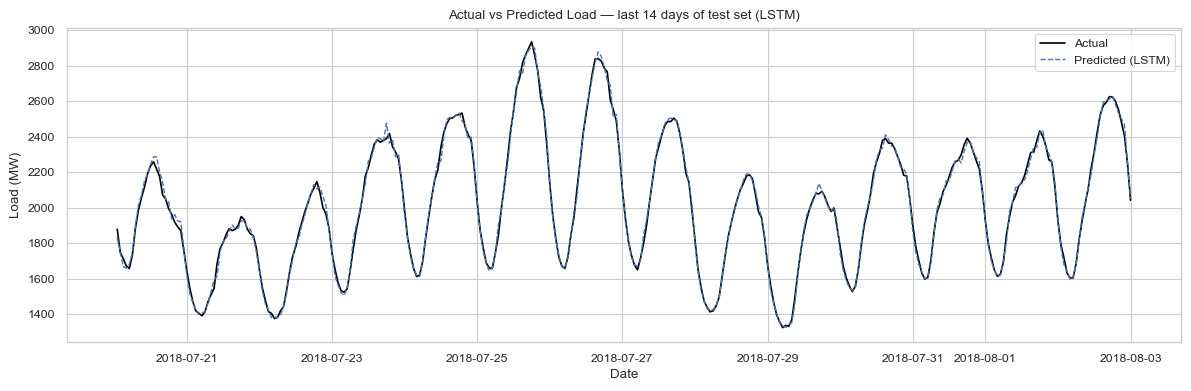

In [37]:
n_hours = 24 * 14
tail = test_df.iloc[-n_hours:].copy()
tail['pred'] = y_pred_best[-n_hours:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tail['Datetime'], tail[TARGET], label='Actual', linewidth=1.2, color='black')
ax.plot(tail['Datetime'], tail['pred'], label=f'Predicted ({best_name})',
        linewidth=1.0, linestyle='--')
ax.set_title(f'Actual vs Predicted Load — last 14 days of test set ({best_name})')
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()


### 4.3 Five-Model Comparison (last 14 days)

All five models overlaid on the same 14-day window so the report has a
single figure showing the spread between paradigms.

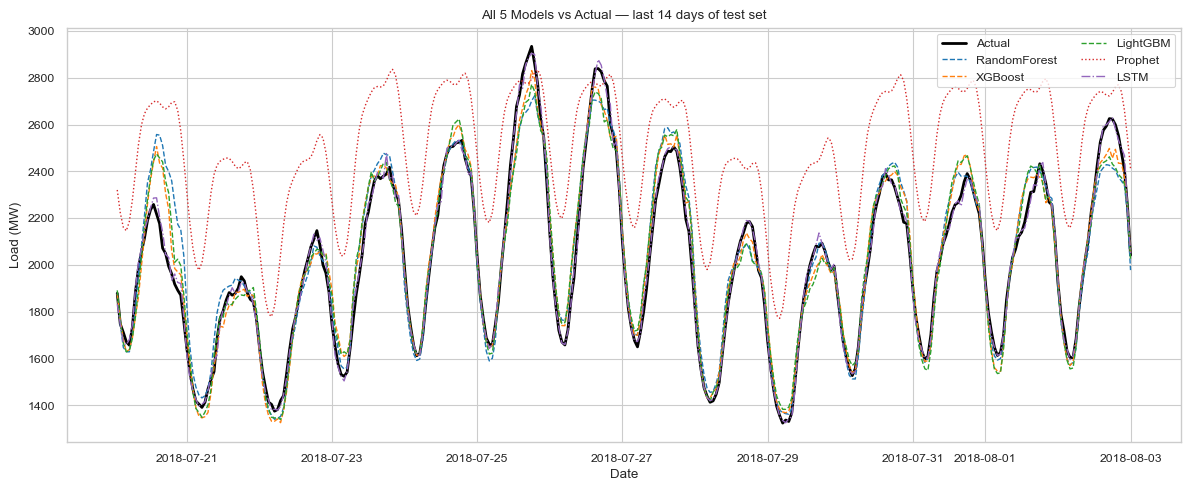

In [38]:
tail_idx = test_df.iloc[-n_hours:].index  # n_hours from the previous cell
tail_dt = test_df.iloc[-n_hours:]['Datetime']
tail_actual = y_test.iloc[-n_hours:].values

model_styles = {
    'RandomForest': {'color': 'tab:blue',   'ls': '--'},
    'XGBoost':      {'color': 'tab:orange', 'ls': '--'},
    'LightGBM':     {'color': 'tab:green',  'ls': '--'},
    'Prophet':      {'color': 'tab:red',    'ls': ':'},
    'LSTM':         {'color': 'tab:purple', 'ls': '-.'},
}

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tail_dt, tail_actual, label='Actual', color='black', linewidth=2.0)
for model_name, preds in test_preds.items():
    style = model_styles[model_name]
    ax.plot(
        tail_dt, preds[-n_hours:],
        label=model_name, linewidth=1.0,
        color=style['color'], linestyle=style['ls'],
    )

ax.set_title('All 5 Models vs Actual — last 14 days of test set')
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig('models_comparison_last14d.png')
plt.show()


### 4.4 Per-Paradigm Comparison

Three vertically stacked panels — one per forecasting paradigm — make it
easier to see *where* each paradigm wins or loses against the actual load
over the same 14-day window. The Discussion section leans on this figure.

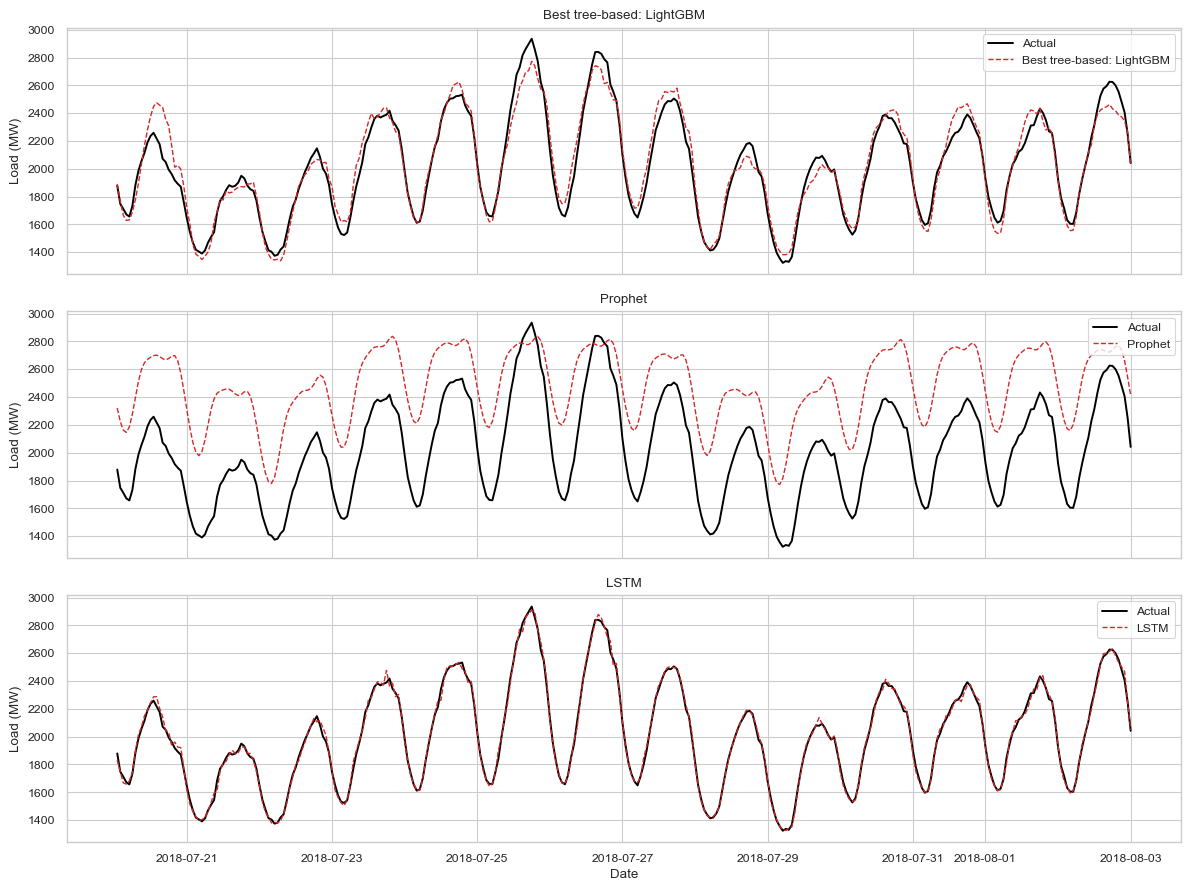

In [39]:
# Three-panel comparison: best tree-based, Prophet, LSTM — each vs Actual.
panels = [
    (f'Best tree-based: {best_tree_name}', test_preds[best_tree_name]),
    ('Prophet',                            test_preds['Prophet']),
    ('LSTM',                               test_preds['LSTM']),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (panel_title, preds) in zip(axes, panels):
    ax.plot(tail_dt, tail_actual, label='Actual', color='black', linewidth=1.4)
    ax.plot(tail_dt, preds[-n_hours:], label=panel_title,
            linewidth=1.0, linestyle='--', color='tab:red')
    ax.set_title(panel_title)
    ax.set_ylabel('Load (MW)')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('per_paradigm_comparison.png')
plt.show()


### 4.5 Feature Importance (top 15)

If the global best model is a tree-based estimator we plot its feature
importances directly. If a non-tree model wins (Prophet or LSTM), we fall
back to the best tree-based model — the per-paradigm comparison above
already covers what the non-tree winner does well or poorly.

Best overall model "LSTM" has no feature_importances_; falling back to best tree-based model "LightGBM".


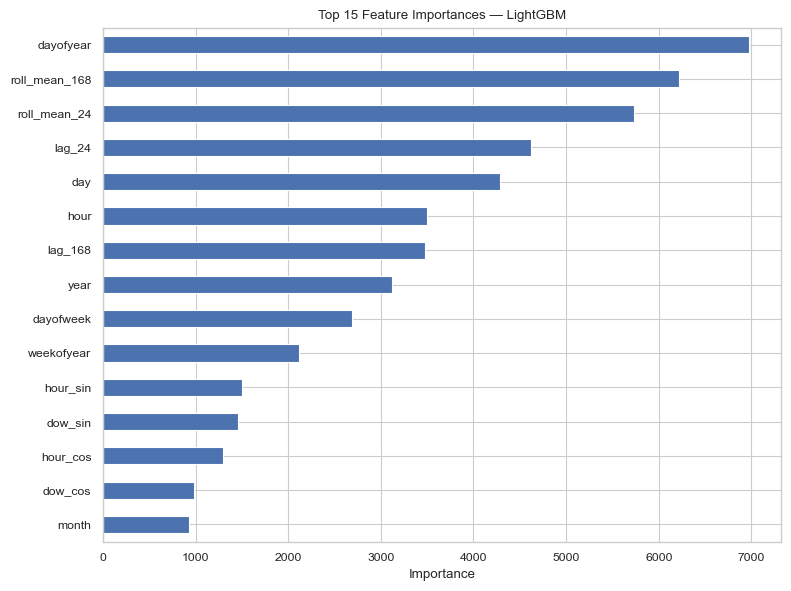

In [40]:
# Pick whichever tree model to display importances for, with a graceful fallback.
if best_name in TREE_MODELS:
    fi_model_name = best_name
else:
    fi_model_name = best_tree_name
    print(f'Best overall model "{best_name}" has no feature_importances_; '
          f'falling back to best tree-based model "{fi_model_name}".')

fi_model = TREE_MODELS[fi_model_name]
importances = pd.Series(
    fi_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax)
ax.set_title(f'Top 15 Feature Importances — {fi_model_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
